Leitura dos dados

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import MDS
from scipy.spatial import Voronoi, voronoi_plot_2d

output_dir = Path("output_notebook_simplificado")
output_dir.mkdir(exist_ok=True, parents=True)

# %%
# 1. Carregar dataset
#df_raw = pd.read_csv("ex1_synthetic_trajectories.csv")
df_raw = pd.read_csv("128_fishing_trajsRugs10.csv")
df_raw = df_raw.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
df_raw.head()

,Unnamed: 0,trajectory_id,timestamp,x,y,bearing,label
0,0,211477000-2,0,705723.070725,6.225237e+06,309.501333,01-sailing
1,1,211477000-2,1,705720.961925,6.225238e+06,300.882654,01-sailing
2,2,211477000-2,2,705718.785662,6.225240e+06,302.344350,01-sailing
3,3,211477000-2,3,705716.469132,6.225241e+06,306.781649,01-sailing
4,4,211477000-2,4,705713.779868,6.225243e+06,302.651628,01-sailing


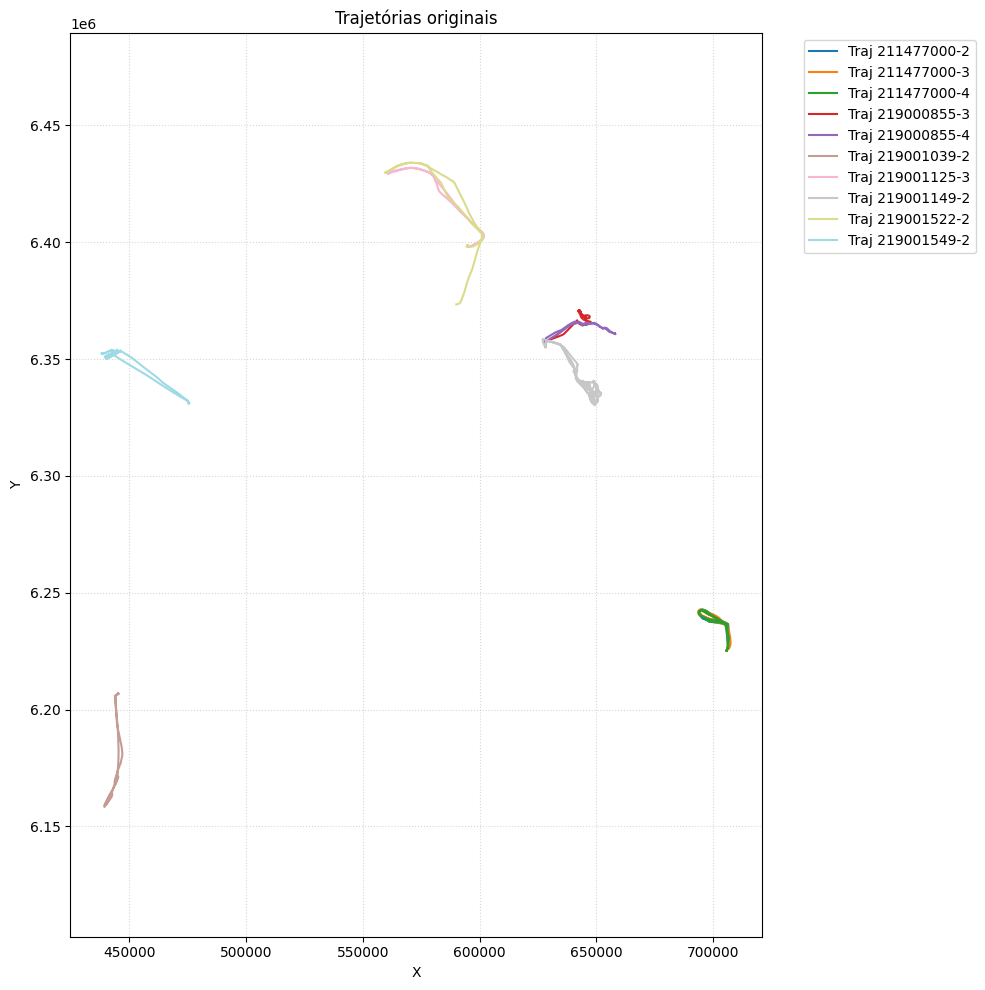

In [118]:
# 2. Plotar trajetórias originais
plt.figure(figsize=(10, 10))
grouped = df_raw.groupby("trajectory_id")
colors = plt.cm.tab20(np.linspace(0, 1, len(grouped)))

for color, (traj_id, g) in zip(colors, grouped):
    g = g.sort_values("timestamp")
    plt.plot(g["x"], g["y"], color=color, label=f"Traj {traj_id}")

plt.title("Trajetórias originais")
plt.xlabel("X"); plt.ylabel("Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axis("equal"); plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "traj_orig.png", dpi=300)
plt.show()
plt.close()


Pré-processamento: translação + PCA rotation

In [119]:
df = df_raw.copy()

df['x_translate'] = df.groupby('trajectory_id')['x'].transform(lambda x: x - x.iloc[0])
df['y_translate'] = df.groupby('trajectory_id')['y'].transform(lambda y: y - y.iloc[0])

angles = {}

def pca_angle(x, y):
    X = np.vstack([x, y]).T
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    disp = np.array([x[-1], y[-1]])
    if np.dot(v1, disp) < 0:
        v1 = -v1
    return np.arctan2(v1[1], v1[0])

df['x_rotated'] = np.nan
df['y_rotated'] = np.nan

for tid, g in df.groupby('trajectory_id'):
    x, y = g['x_translate'].to_numpy(), g['y_translate'].to_numpy()
    theta = pca_angle(x, y)
    c, s = np.cos(-theta), np.sin(-theta)
    xr = x * c - y * s
    yr = x * s + y * c
    df.loc[g.index, 'x_rotated'] = xr
    df.loc[g.index, 'y_rotated'] = yr
    angles[tid] = theta


Métricas: Velocidade e ângulo

In [120]:
df = df.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
window = 1

def compute_speed_angle(g):
    dx = g["x_rotated"] - g["x_rotated"].shift(window)
    dy = g["y_rotated"] - g["y_rotated"].shift(window)
    g["speed"] = np.hypot(dx, dy)
    g["angle_deg"] = np.degrees(np.arctan2(dy, dx))
    return g

df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)

C:\Users\ccana\AppData\Local\Temp\ipykernel_33640\2813627076.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)


Discretização simbólica

In [121]:
median_speed = float(np.nanmedian(df["speed"]))
eps = 1e-3 * median_speed if median_speed > 0 else 1e-6
moving = df["speed"] > eps
q25, q75 = np.quantile(df.loc[moving, "speed"], [0.25, 0.75]) if moving.any() else (0, 0)

def label_speed(v):
    if np.isnan(v): return np.nan
    if v <= eps: return "Parado"
    if v <= q25: return "Lento"
    if v <= q75: return "Médio"
    return "Rápido"

def label_dir(a):
    if np.isnan(a): return np.nan
    a = ((a + 180) % 360) - 180
    if -45 < a <= 45: return "Leste"
    if 45 < a <= 135: return "Norte"
    if a > 135 or a <= -135: return "Oeste"
    return "Sul"

df["speed_label"] = df["speed"].apply(label_speed)
df["dir4_label"] = df["angle_deg"].apply(label_dir)

def combine(s, d):
    if pd.isna(s): return ""
    if s == "Parado": return "Parado"
    if pd.isna(d): return ""
    return s + d

df["symbol"] = df.apply(lambda r: combine(r["speed_label"], r["dir4_label"]), axis=1)

# Lista por trajetória
symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())
symbolic = symbolic.rename("simbolic_movement").reset_index()

symbolic

C:\Users\ccana\AppData\Local\Temp\ipykernel_33640\3476485095.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())


,trajectory_id,simbolic_movement
0,211477000-2,"[, LentoOeste, LentoOeste, LentoOeste, LentoOe..."
1,211477000-3,"[, LentoNorte, LentoNorte, LentoNorte, LentoNo..."
2,211477000-4,"[, LentoSul, LentoSul, LentoSul, MédioSul, Len..."
3,219000855-3,"[, LentoSul, LentoSul, LentoSul, LentoSul, Len..."
4,219000855-4,"[, MédioLeste, LentoLeste, MédioLeste, LentoSu..."
5,219001039-2,"[, LentoLeste, LentoLeste, LentoLeste, LentoLe..."
6,219001125-3,"[, LentoNorte, LentoNorte, LentoOeste, MédioOe..."
7,219001149-2,"[, RápidoOeste, MédioOeste, MédioOeste, LentoS..."
8,219001522-2,"[, LentoOeste, LentoSul, LentoSul, LentoSul, M..."
9,219001549-2,"[, MédioOeste, LentoOeste, LentoOeste, MédioOe..."


Construir Unique Subsets (CDM)

In [122]:
symbols = sorted(df["symbol"].dropna().unique())
attr_sets = {s: set([s]) for s in symbols}  # cada símbolo é um estado semântico puro
symbols


['',
 'LentoLeste',
 'LentoNorte',
 'LentoOeste',
 'LentoSul',
 'MédioLeste',
 'MédioNorte',
 'MédioOeste',
 'MédioSul',
 'RápidoLeste',
 'RápidoNorte',
 'RápidoOeste',
 'RápidoSul']

Jaccard

In [123]:
def jaccard_distance_matrix(symbols, attr_sets):
    n=len(symbols)
    D=np.zeros((n,n))
    for i,a in enumerate(symbols):
        for j,b in enumerate(symbols):
            A,B = attr_sets[a], attr_sets[b]
            D[i,j] = 1 - len(A & B)/len(A | B)
    return D

D = jaccard_distance_matrix(symbols, attr_sets)
D


array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.]])

MDS + Voronoi

C:\Users\ccana\AppData\Local\Temp\ipykernel_33640\2633891947.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(symbols))


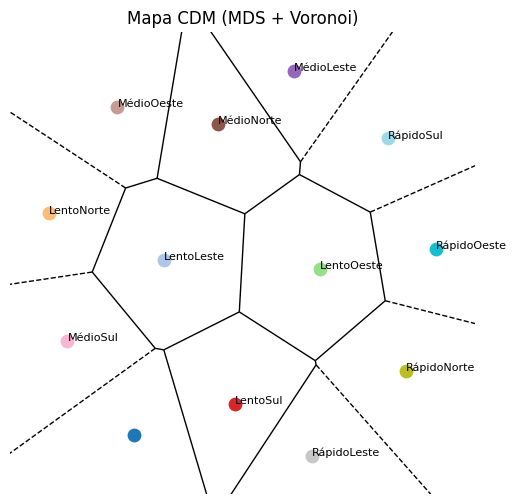

In [124]:
coords = MDS(dissimilarity="precomputed", random_state=0).fit_transform(D)

fig, ax = plt.subplots(figsize=(6,6))
try:
    vor = Voronoi(coords)
    voronoi_plot_2d(vor, ax=ax, show_vertices=False, show_points=False)
except:
    print("Voronoi falhou")

colors = plt.cm.get_cmap("tab20", len(symbols))
for i,p in enumerate(coords):
    ax.scatter(p[0], p[1], color=colors(i), s=80)
    ax.text(p[0], p[1], symbols[i], fontsize=8)

ax.set_title("Mapa CDM (MDS + Voronoi)")
ax.axis("off")
plt.show()


Construção da Matriz de Transição de Markov por trajetória

In [125]:
# -------------------------------------------------------------------
# Construir df_feat com os dados necessários (equivalente ao seu df)
# -------------------------------------------------------------------
df = df.copy()

# Cada símbolo pertence a uma região do Voronoi → definir estado_idx
symbol_regions = {sym: vor.point_region[i] for i, sym in enumerate(symbols)}

df["state_idx"] = df["symbol"].map(symbol_regions).astype(int)

df.head()


,Unnamed: 0,trajectory_id,timestamp,x,y,bearing,label,x_translate,y_translate,x_rotated,y_rotated,speed,angle_deg,speed_label,dir4_label,symbol,state_idx
0,0,211477000-2,0,705723.070725,6.225237e+06,309.501333,01-sailing,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,,2
1,1,211477000-2,1,705720.961925,6.225238e+06,300.882654,01-sailing,-2.108800,1.125075,-2.272788,-0.739775,2.390153,-161.970329,Lento,Oeste,LentoOeste,10
2,2,211477000-2,2,705718.785662,6.225240e+06,302.344350,01-sailing,-4.285063,2.358398,-4.670357,-1.453124,2.501440,-163.430674,Lento,Oeste,LentoOeste,10
3,3,211477000-2,3,705716.469132,6.225241e+06,306.781649,01-sailing,-6.601593,3.919443,-7.401351,-2.040359,2.793416,-167.864690,Lento,Oeste,LentoOeste,10
4,4,211477000-2,4,705713.779868,6.225243e+06,302.651628,01-sailing,-9.290857,5.462590,-10.377853,-2.908621,3.100555,-163.737737,Lento,Oeste,LentoOeste,10


In [126]:
import numpy as np
import pandas as pd

# --- construir alfabeto global de símbolos ---
all_symbols = sorted({s for seq in symbolic["simbolic_movement"] for s in seq if s != ""})
sym2idx = {s: i for i, s in enumerate(all_symbols)}

print("Alfabeto simbólico:", all_symbols)

def build_transition_matrix(sequence, sym2idx):
    """
    Cria matriz de transição de Markov de 1ª ordem para uma sequência simbólica.
    """
    n = len(sym2idx)
    M = np.zeros((n, n))

    clean = [s for s in sequence if s != ""]
    for a, b in zip(clean[:-1], clean[1:]):
        i, j = sym2idx[a], sym2idx[b]
        M[i, j] += 1

    # normalizar linhas
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return M / row_sums


Alfabeto simbólico: ['LentoLeste', 'LentoNorte', 'LentoOeste', 'LentoSul', 'MédioLeste', 'MédioNorte', 'MédioOeste', 'MédioSul', 'RápidoLeste', 'RápidoNorte', 'RápidoOeste', 'RápidoSul']


In [127]:
transition_vectors = []

for seq in symbolic["simbolic_movement"]:
    P = build_transition_matrix(seq, sym2idx)
    transition_vectors.append(P.flatten())

df_markov = pd.DataFrame(transition_vectors)
df_markov["trajectory_id"] = symbolic["trajectory_id"]

df_markov.head()


,0,1,2,3,4,5,6,7,8,9,...,135,136,137,138,139,140,141,142,143,trajectory_id
0,0.580357,0.026786,0.013393,0.044643,0.281250,0.004464,0.0,0.0,0.049107,0.0,...,0.066667,0.000000,0.0,0.0,0.866667,0.000000,0.0,0.0,0.066667,211477000-2
1,0.386364,0.128788,0.000000,0.007576,0.401515,0.007576,0.0,0.0,0.060606,0.0,...,0.063063,0.000000,0.0,0.0,0.162162,0.018018,0.0,0.0,0.756757,211477000-3
2,0.398907,0.000000,0.000000,0.010929,0.530055,0.005464,0.0,0.0,0.054645,0.0,...,0.025000,0.000000,0.0,0.0,0.029167,0.008333,0.0,0.0,0.937500,211477000-4
3,0.701220,0.018293,0.000000,0.036585,0.176829,0.006098,0.0,0.0,0.060976,0.0,...,0.058333,0.000000,0.0,0.0,0.466667,0.025000,0.0,0.0,0.450000,219000855-3
4,0.754237,0.002825,0.000000,0.019774,0.152542,0.000000,0.0,0.0,0.070621,0.0,...,0.052632,0.010526,0.0,0.0,0.347368,0.000000,0.0,0.0,0.589474,219000855-4


In [128]:
from sklearn.cluster import AgglomerativeClustering

X = df_markov.drop(columns=["trajectory_id"]).values

n_clusters = 10   # ajuste se quiser

clustering = AgglomerativeClustering(n_clusters=n_clusters)
cluster_ids = clustering.fit_predict(X)

df_markov["cluster_markov"] = cluster_ids

symbolic_markov = symbolic.copy()
symbolic_markov["cluster_markov"] = cluster_ids

symbolic_markov.head()


,trajectory_id,simbolic_movement,cluster_markov
0,211477000-2,"[, LentoOeste, LentoOeste, LentoOeste, LentoOe...",5
1,211477000-3,"[, LentoNorte, LentoNorte, LentoNorte, LentoNo...",6
2,211477000-4,"[, LentoSul, LentoSul, LentoSul, MédioSul, Len...",7
3,219000855-3,"[, LentoSul, LentoSul, LentoSul, LentoSul, Len...",8
4,219000855-4,"[, MédioLeste, LentoLeste, MédioLeste, LentoSu...",2


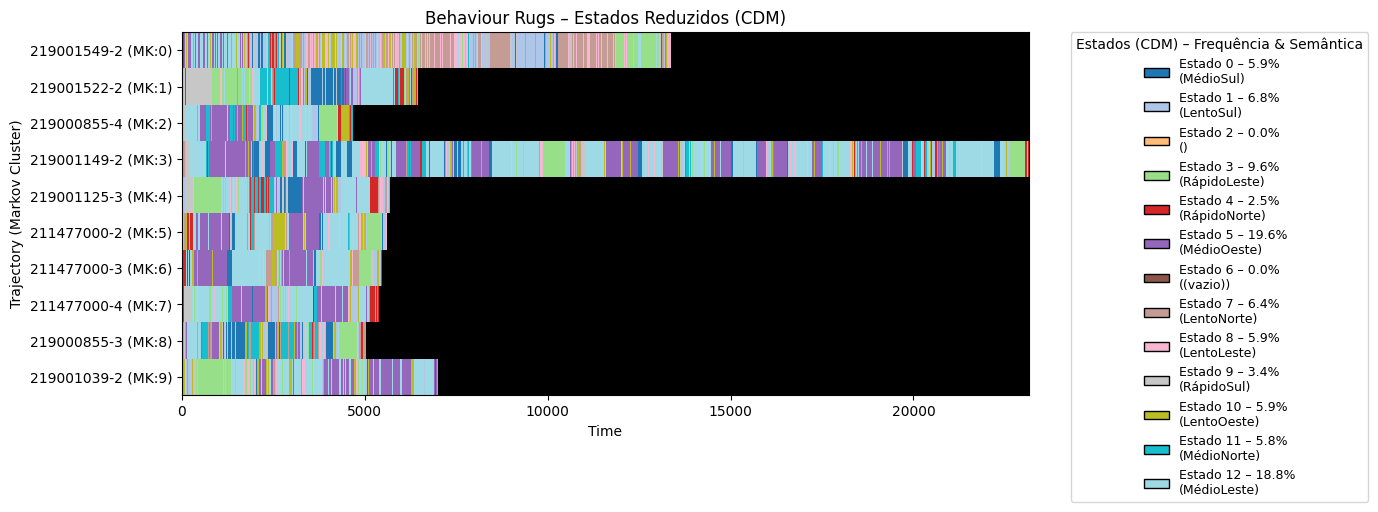

In [129]:
# ========================================================
# Preparação: estados, cores, frequência e semântica
# ========================================================

# Número de estados reduzidos
num_states = df["state_idx"].nunique()
cmap = plt.get_cmap("tab20", num_states)

# Frequência dos estados (%)
state_freq = df["state_idx"].value_counts(normalize=True).sort_index() * 100

# Construção da semântica do estado:
# Cada estado é um conjunto de símbolos originais associados ao cluster CDM
state_semantics = (
    df.groupby("state_idx")["symbol"]
    .apply(lambda x: sorted(x.dropna().unique()))
)

# ========================================================
# Construção das sequências por trajetória
# ========================================================
state_sequences = (
    df
    .sort_values("timestamp")
    .groupby("trajectory_id")["state_idx"]
    .apply(list)
    .reset_index(name="state_seq")
)

# Juntar com cluster Markov para ordenar
state_sequences = state_sequences.merge(
    symbolic_markov[["trajectory_id","cluster_markov"]],
    on="trajectory_id"
).sort_values("cluster_markov")

max_len = max(len(seq) for seq in state_sequences["state_seq"])
img = np.zeros((len(state_sequences), max_len, 3))

for i, seq in enumerate(state_sequences["state_seq"]):
    row_colors = [cmap(s)[:3] for s in seq]
    row_colors += [[0,0,0]] * (max_len - len(row_colors))
    img[i] = row_colors

# ========================================================
# Plot dos BehaviourRugs
# ========================================================
fig, ax = plt.subplots(figsize=(14, 0.5 * len(state_sequences)))
ax.imshow(img, aspect="auto", interpolation="nearest")

ax.set_yticks(range(len(state_sequences)))
ax.set_yticklabels(
    state_sequences["trajectory_id"].astype(str) +
    " (MK:" + state_sequences["cluster_markov"].astype(str) + ")"
)

ax.set_xlabel("Time")
ax.set_ylabel("Trajectory (Markov Cluster)")
ax.set_title("Behaviour Rugs – Estados Reduzidos (CDM)")

# ========================================================
# LEGENDA SEMÂNTICA
# ========================================================
from matplotlib.patches import Patch

legend_elements = []

for s in range(num_states):

    # Se o estado não existe no df -> estado vazio
    if s in state_freq.index:
        freq = state_freq.loc[s]
    else:
        freq = 0.0

    if s in state_semantics.index:
        semantics = state_semantics.loc[s]
    else:
        semantics = ["(vazio)"]

    # Texto amigável
    sem_text = ", ".join(semantics[:4])
    if len(semantics) > 4:
        sem_text += ", ..."

    label = f"Estado {s} – {freq:.1f}%\n({sem_text})"

    legend_elements.append(
        Patch(facecolor=cmap(s), edgecolor='black', label=label)
    )


legend = ax.legend(
    handles=legend_elements,
    title="Estados (CDM) – Frequência & Semântica",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9,
    borderaxespad=0.
)

plt.tight_layout()
plt.show()
